In [36]:
# CELL 22: Clustering - GMM with BIC-selected k
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Test k from 2 to 15
max_k = 15
bic_scores = []
models = []

for k in range(2, max_k + 1):
    gmm = GaussianMixture(n_components=k, random_state=SEED, n_init=5)
    labels = gmm.fit_predict(embeddings)
    bic_scores.append(gmm.bic(embeddings))
    models.append((k, gmm, labels))

bic_scores = np.array(bic_scores)
optimal_k = np.argmin(bic_scores) + 2  # +2 because range started at 2

print(f"Optimal k by BIC: {optimal_k}")
print(f"BIC scores: {dict(zip(range(2, max_k+1), bic_scores.round(1)))}")

# Use optimal model
best_gmm, trajectory_labels = models[optimal_k - 2][1], models[optimal_k - 2][2]
print(f"\nCluster distribution:")
print(pd.Series(trajectory_labels).value_counts())

Optimal k by BIC: 15
BIC scores: {2: np.float64(-40223.4), 3: np.float64(-52041.8), 4: np.float64(-55488.1), 5: np.float64(-56596.9), 6: np.float64(-61788.7), 7: np.float64(-62478.3), 8: np.float64(-63500.4), 9: np.float64(-62875.1), 10: np.float64(-79431.4), 11: np.float64(-79750.3), 12: np.float64(-83787.3), 13: np.float64(-83949.0), 14: np.float64(-85152.6), 15: np.float64(-91090.0)}

Cluster distribution:
1     797
0     465
10    343
8     280
9     216
13    189
2     180
11    133
4     129
5     129
6     100
3      62
14      4
7       2
12      1
Name: count, dtype: int64


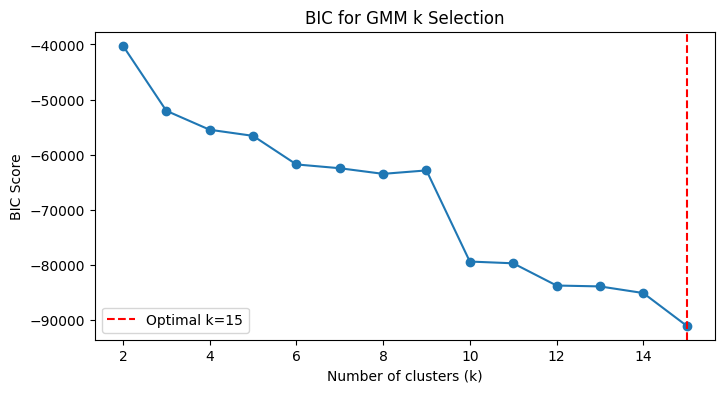

In [37]:
# CELL 23: Plot BIC curve
plt.figure(figsize=(8, 4))
plt.plot(range(2, max_k+1), bic_scores, marker='o')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('BIC Score')
plt.title('BIC for GMM k Selection')
plt.legend()
plt.show()

In [38]:
# CELL 24: Internal validation metrics
sil_score = silhouette_score(embeddings, trajectory_labels)
db_score = davies_bouldin_score(embeddings, trajectory_labels)

print(f"Trajectory VAE + GMM (k={optimal_k}):")
print(f"  Silhouette Score: {sil_score:.4f}")
print(f"  Davies-Bouldin Index: {db_score:.4f}")

Trajectory VAE + GMM (k=15):
  Silhouette Score: 0.1763
  Davies-Bouldin Index: 1.9838


In [39]:
# CELL 25 (fixed): Baseline 1 - Static K-Means
static_rfm = train_df.groupby('Customer ID').agg(
    recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('TotalPrice', 'sum'),
    avg_order_value=('TotalPrice', 'mean')
).reset_index()

static_rfm['Customer ID'] = static_rfm['Customer ID'].astype(str)

# Keep only customers present in both
common_ids = list(set(static_rfm['Customer ID']) & set(customer_ids))
print(f"Customers in both: {len(common_ids)}")

static_data = static_rfm.set_index('Customer ID').loc[common_ids].values
static_scaled = StandardScaler().fit_transform(static_data)

static_kmeans = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10)
static_labels = static_kmeans.fit_predict(static_scaled)

static_sil = silhouette_score(static_scaled, static_labels)
static_db = davies_bouldin_score(static_scaled, static_labels)

print(f"Static K-Means (k={optimal_k}):")
print(f"  Silhouette Score: {static_sil:.4f}")
print(f"  Davies-Bouldin Index: {static_db:.4f}")

Customers in both: 3008
Static K-Means (k=15):
  Silhouette Score: 0.3819
  Davies-Bouldin Index: 0.7281


In [40]:
# CELL 25b: Define StaticVAE class
class StaticVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU()
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

print("StaticVAE class defined.")

StaticVAE class defined.


In [41]:
# Fix missing import
import torch.nn.functional as F

In [42]:
# CELL 26 (fixed): Baseline 2 - Static VAE + K-Means
X_static = torch.FloatTensor(static_scaled).to(device)
static_vae = StaticVAE(input_dim=static_scaled.shape[1], latent_dim=8).to(device)
optimizer = torch.optim.Adam(static_vae.parameters(), lr=1e-3)

for epoch in range(100):
    optimizer.zero_grad()
    recon, mu, logvar = static_vae(X_static)
    recon_loss = F.mse_loss(recon, X_static)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss = recon_loss + 0.1 * kl_loss
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 | Loss: {loss.item():.4f}")

static_vae.eval()
with torch.no_grad():
    _, mu_static, _ = static_vae(X_static)
    static_embeddings = mu_static.cpu().numpy()

static_vae_kmeans = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10)
static_vae_labels = static_vae_kmeans.fit_predict(static_embeddings)

static_vae_sil = silhouette_score(static_embeddings, static_vae_labels)
static_vae_db = davies_bouldin_score(static_embeddings, static_vae_labels)

print(f"\nStatic VAE + K-Means (k={optimal_k}):")
print(f"  Silhouette Score: {static_vae_sil:.4f}")
print(f"  Davies-Bouldin Index: {static_vae_db:.4f}")

Epoch 20/100 | Loss: 0.9449
Epoch 40/100 | Loss: 0.6269
Epoch 60/100 | Loss: 0.2880
Epoch 80/100 | Loss: 0.2151
Epoch 100/100 | Loss: 0.1789

Static VAE + K-Means (k=15):
  Silhouette Score: 0.4612
  Davies-Bouldin Index: 0.6742


In [43]:
# CELL 27: Summary comparison
print("=" * 50)
print("INTERNAL METRICS COMPARISON")
print("=" * 50)
print(f"{'Method':<30} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-" * 50)
print(f"{'Trajectory VAE + GMM':<30} {sil_score:<15.4f} {db_score:<15.4f}")
print(f"{'Static K-Means':<30} {static_sil:<15.4f} {static_db:<15.4f}")
print(f"{'Static VAE + K-Means':<30} {static_vae_sil:<15.4f} {static_vae_db:<15.4f}")
print("=" * 50)

INTERNAL METRICS COMPARISON
Method                         Silhouette      Davies-Bouldin 
--------------------------------------------------
Trajectory VAE + GMM           0.1763          1.9838         
Static K-Means                 0.3819          0.7281         
Static VAE + K-Means           0.4612          0.6742         


In [44]:
# CELL 28: Prepare holdout labels for external validation
# Churn = no purchase in the holdout period
holdout_df = df_traj[df_traj['purchase_month'].isin(holdout_months)]

churn_labels = {}
for cid in common_ids:
    churn_labels[cid] = 1 if cid not in holdout_df['Customer ID'].astype(str).values else 0

y_churn = np.array([churn_labels[cid] for cid in common_ids])
print(f"Churn rate in holdout: {y_churn.mean():.2%}")
print(f"Total customers: {len(y_churn)}")

Churn rate in holdout: 38.73%
Total customers: 3008


In [45]:
# CELL 29: Prepare feature sets for prediction
# Align trajectory labels to common_ids
traj_labels_aligned = np.array([trajectory_labels[customer_ids.index(cid)] for cid in common_ids])

# Static features (from CELL 25)
static_features = static_scaled

# Trajectory embedding features
traj_features = np.array([embeddings[customer_ids.index(cid)] for cid in common_ids])

print(f"Trajectory labels shape: {traj_labels_aligned.shape}")
print(f"Static features shape: {static_features.shape}")
print(f"Trajectory embedding shape: {traj_features.shape}")

Trajectory labels shape: (3008,)
Static features shape: (3008, 4)
Trajectory embedding shape: (3008, 8)


Surrogate fidelity (k=5): 62.83%


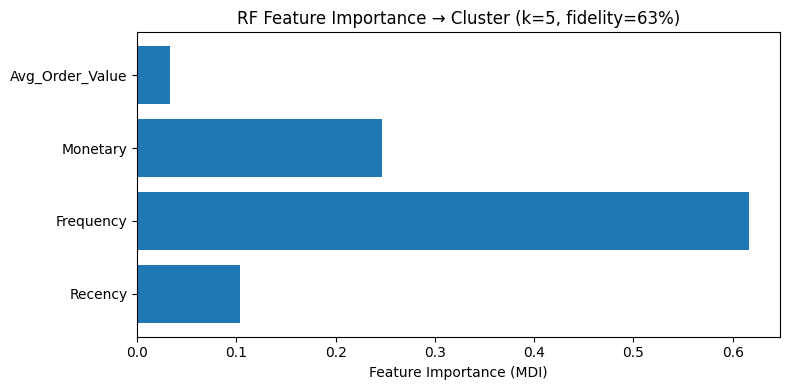


Per-Cluster Static RFM Means (k=5):
         Recency  Frequency  Monetary  Avg_Order_Value
Cluster                                               
0          -0.01       0.28      0.05            -0.00
1           0.03      -0.35     -0.18            -0.08
2          -0.50       0.39      0.10             0.13
3          -0.33       3.38      2.74             1.41
4           0.21      -0.22     -0.14            -0.10

Cluster sizes:
Cluster
0     540
1    1219
2     334
3      98
4     817
Name: count, dtype: int64


In [57]:
# CELL 41: Surrogate fidelity with k=5
surrogate_k5 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
surrogate_k5.fit(static_features, traj_labels_k5_aligned)
surrogate_acc_k5 = surrogate_k5.score(static_features, traj_labels_k5_aligned)
print(f"Surrogate fidelity (k={k_fixed}): {surrogate_acc_k5:.2%}")

# Feature importance
importances_k5 = surrogate_k5.feature_importances_
plt.figure(figsize=(8, 4))
plt.barh(static_feature_names, importances_k5)
plt.xlabel('Feature Importance (MDI)')
plt.title(f'RF Feature Importance → Cluster (k={k_fixed}, fidelity={surrogate_acc_k5:.0%})')
plt.tight_layout()
plt.show()

# Per-cluster means
print("\nPer-Cluster Static RFM Means (k=5):")
cluster_means_k5 = pd.DataFrame(static_features, columns=static_feature_names)
cluster_means_k5['Cluster'] = traj_labels_k5_aligned
print(cluster_means_k5.groupby('Cluster').mean().round(2))
print(f"\nCluster sizes:")
print(cluster_means_k5['Cluster'].value_counts().sort_index())